<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
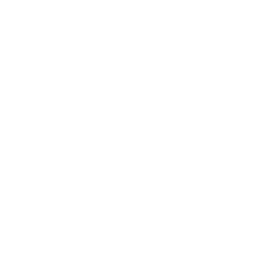
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Split-plot-design för processoptimering</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Tillverkning / Kvalitetsteknik &nbsp;|&nbsp; Mars 2026</p>
</div>
</div>
</div>

## Sammanfattning

Den här notebooken analyserar ett split-plot-designat experiment för en formsprutningsprocess. Whole-plot-faktorn är **maskin** (4 nivåer: MACH_A-MACH_D), som är svår att ändra, och sub-plot-faktorn är **hastighetsinställning** (5 nivåer: 60, 80, 100, 120, 140 RPM), som är lätt att ändra. Fem replikatmätningar tas vid varje kombination av maskin och hastighet, vilket ger 100 observationer av felfrekvens.

`PROC MIXED` anpassar den restrikterade randomiseringsstrukturen korrekt genom att behandla **maskin som en slumpeffekt** (whole-plot-felstratumet) och **hastighet som en fix effekt** (sub-plot-faktorn). Analysen skattar de två varianskomponenterna, testar hastighetseffekten och tar fram Tukey-justerade parvisa jämförelser av hastighetens minsta-kvadratmedelvärden för att identifiera den driftshastighet som minimerar felfrekvensen.


## Datakällor

| Källa | Beskrivning | Poster |
|--------|-------------|--------|
| WORK.MOLDING_EXPERIMENT | Split-plot-experimentdata: 4 maskiner x 5 hastigheter x 5 replikat | 100 |


---

In [1]:
/* --------------------------------------------------------
   Generera syntetiska split-plot-data för formsprutning
   4 maskiner (whole-plot) x 5 hastigheter (sub-plot) x 5 rep
   Ytterligare replikat för varje whole-plot
   -------------------------------------------------------- */
data work.molding_experiment;
    CALL streaminit(42);
    FÄLT machine_names[4] $12 _temporary_ ('MACH_A' 'MACH_B' 'MACH_C' 'MACH_D');
    FÄLT speed_settings[5] _temporary_ (60 80 100 120 140);
    /* Sanna maskineffekter (slumpmässiga) */
    FÄLT mach_eff[4] _temporary_ (2.1 -1.5 0.8 -1.4);
    /* Sanna hastighetseffekter (fixa, kvadratiska med optimum ~100) */
    FÄLT speed_eff[5] _temporary_ (3.2 1.0 -0.5 0.8 4.5);
    obs_id = 0;
    GÖR whole_plot = 1 TILL 5;
        GÖR m = 1 TILL 4;
            machine = machine_names[m];
            machine_id = cat('WP_', put(whole_plot, z2.), '_', machine);
            /* Whole-plot-replikateffekt */
            wp_noise = rand('normal', 0, 1.5);
            GÖR s = 1 TILL 5;
                speed = speed_settings[s];
                speed_label = cat(put(speed, 3.), 'RPM');
                /* Sub-plot-replikat inom varje whole-plot */
                GÖR rep = 1 TILL 5;
                    obs_id + 1;
                    /* Felfrekvens: intercept + maskin + hastighet + interaktion + brus */
                    defect_rate = round(
                        8.0 + mach_eff[m] + speed_eff[s] +
                        wp_noise +
                        0.3 * (m - 2) * (s - 3) +
                        rand('normal', 0, 1.2),
                    0.01);
                    OM defect_rate < 0 SÅ defect_rate = 0.01;
                    /* Sekundär respons: draghållfasthet */
                    tensile_strength = round(
                        45 - 0.5 * defect_rate +
                        rand('normal', 0, 2),
                    0.1);
                    UTDATA;
                SLUT;
            SLUT;
        SLUT;
    SLUT;
    TA_BORT m s mach_eff1-mach_eff4 speed_eff1-speed_eff5 wp_noise;
KÖR;



NOTE: DATA work.molding_experiment

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.molding_experiment (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.06 seconds
  cpu   0.06 seconds


---

In [2]:
/* --------------------------------------------------------
   Baslinje: sammanfattning av felfrekvens per maskin och hastighet
   -------------------------------------------------------- */
PROCEDUR MEANS data=work.molding_experiment n mean std;
    KLASS machine speed_label;
    VARIABEL defect_rate tensile_strength;
    ETIKETT machine="Maskin" speed_label="Hastighet" defect_rate="Felfrekvens (%)" tensile_strength="Draghållfasthet";
    TITEL 'Felfrekvens och draghållfasthet per maskin och hastighet';
KÖR;


                                Felfrekvens och draghållfasthet per maskin och hastighet                                

                                                  The MEANS Procedure

                                    Analysis Variable : defect_rate Felfrekvens (%)

        Maskin    Hastighet          N Obs           Mean        Std Dev
        ----------------------------------------------------------------
        MACH_A     60RPM                 5     12.9460000      1.0100149
        MACH_A     80RPM                 5     10.0160000      0.6740401
        MACH_A    100RPM                 5      7.5980000      0.9787083
        MACH_A    120RPM                 5     10.2660000      0.9490416
        MACH_A    140RPM                 5     13.7120000      0.9359594
        MACH_B     60RPM                 5     11.7420000      0.9476656
        MACH_B     80RPM                 5      8.5580000      1.0129018
        MACH_B    100RPM                 5      6.5840000      0.


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                                Felfrekvens och draghållfasthet per maskin och hastighet                                




NOTE: PROC MEANS
NOTE: Output dataset work.cell_means has 30 observations and 5 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC SGPLOT data=work.cell_means

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


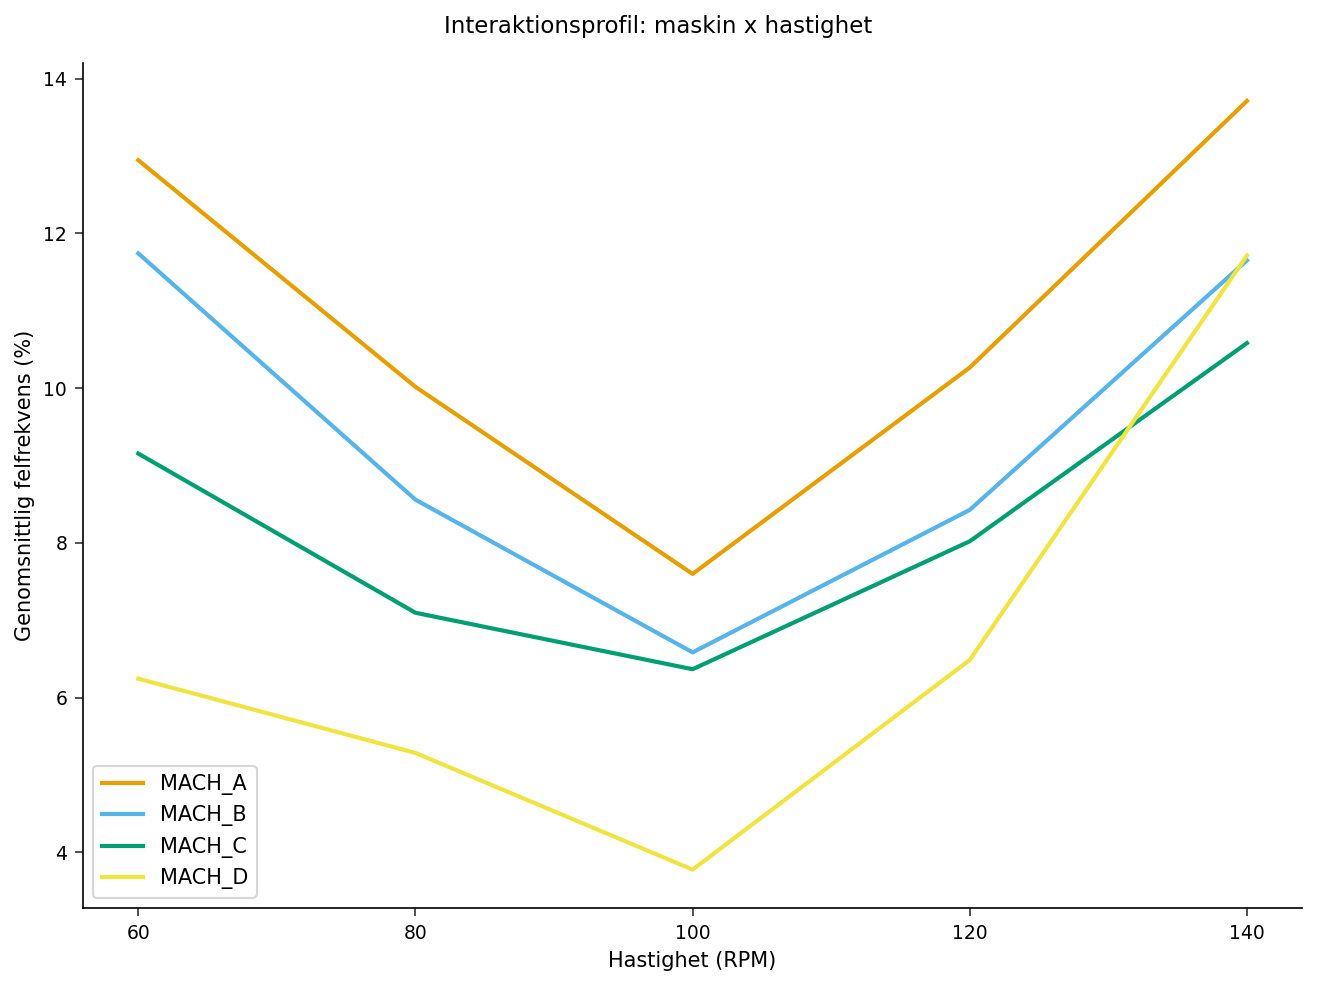

In [3]:
/* --------------------------------------------------------
   Interaktionsdiagram: medelvärde av felfrekvens per hastighet och maskin
   -------------------------------------------------------- */
PROCEDUR MEANS data=work.molding_experiment NOPRINT;
    KLASS machine speed;
    VARIABEL defect_rate;
    UTDATA out=work.cell_means mean=mean_defect;
KÖR;

PROCEDUR SGPLOT data=work.cell_means(where=(_type_=3));
    SERIES x=speed y=mean_defect / GROUP=machine
        LINEATTRS=(thickness=2) MARKERS;
    XAXIS ETIKETT='Hastighet (RPM)' VALUES=(60 80 100 120 140);
    YAXIS ETIKETT='Genomsnittlig felfrekvens (%)';
    TITEL 'Interaktionsprofil: maskin x hastighet';
KÖR;


---

                                Felfrekvens och draghållfasthet per maskin och hastighet                                

           The Mixed Procedure            
            Model Information             

Item                                 Value
-------------------------  ---------------
Dependent Variable         Felfrekvens (%)
Estimation Method                     REML
Degrees of Freedom Method    Kenward-Roger
Number of Observations                 100

Covariance Parameter Estimates

Cov Parm   Subject   Estimate
---------  --------  --------
Intercept  machine     3.1033
Residual               1.6566

         Type III Tests of Fixed Effects         

Effect       Num DF    Den DF   F Value    Pr > F
---------  --------  --------  --------  --------
Hastighet         4      92.0     60.26    <.0001

         Fit Statistics          

Statistic                   Value
-----------------------  --------
-2 Res Log Likelihood    347.3514
AIC (Smaller is Better)  361.3513
BIC (S


NOTE: PROC MIXED data=work.molding_experiment

NOTE: PROC MIXED: using R wrapper (mixed_renderer.R).
NOTE: PROC MIXED results written to: ./ods_output/mixed_results.spec.json
NOTE: lmer formula: defect_rate ~ speed_label + (1 | machine)
NOTE: Warning message:
NOTE: In readLines(con = "stdin") : incomplete final line found on 'stdin'
NOTE: ODS plot written: mixed_residuals_vs_predicted.spec.json
NOTE: ODS plot written: mixed_residual_histogram_panel.spec.json
NOTE: ODS plot written: mixed_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: mixed_qq_plot.spec.json
NOTE: ODS plot written: mixed_diagnostics.spec.json
NOTE: PROC MIXED ODS Graphics generated.
NOTE: ODS OUTPUT: SolutionF written to 'split_fixed'.
NOTE: ODS OUTPUT: CovParms written to 'split_covparms'.
NOTE: ODS OUTPUT: LSMeans written to 'speed_lsmeans'.
NOTE: ODS OUTPUT: FitStatistics written to 'split_fit'.
NOTE: ODS OUTPUT: Diffs written to 'speed_diffs'.


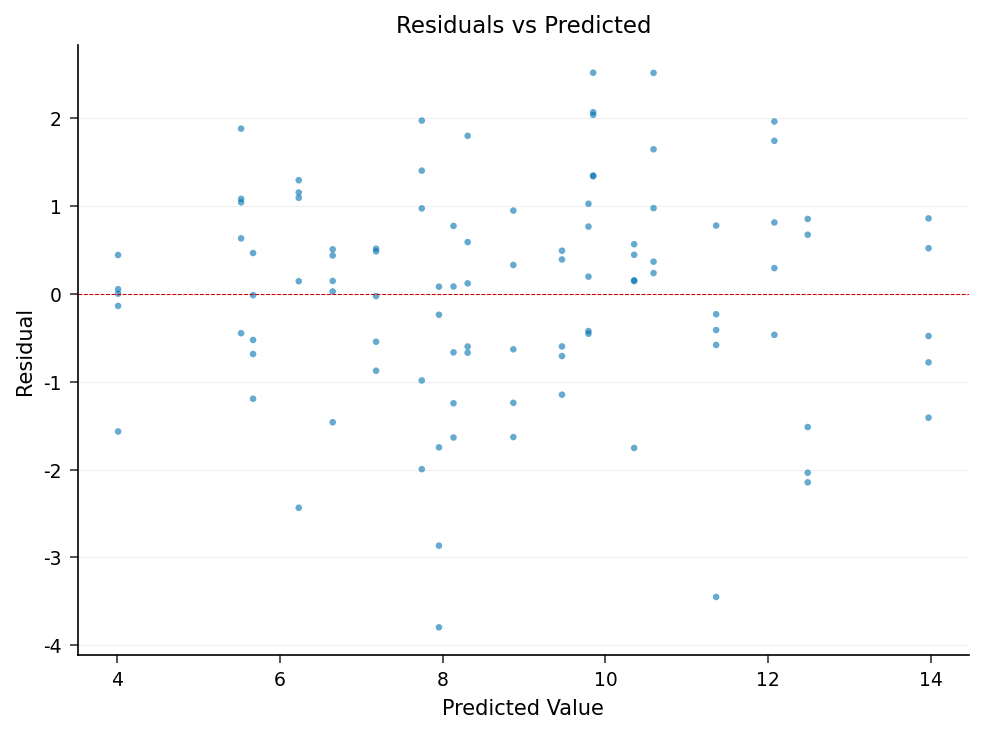

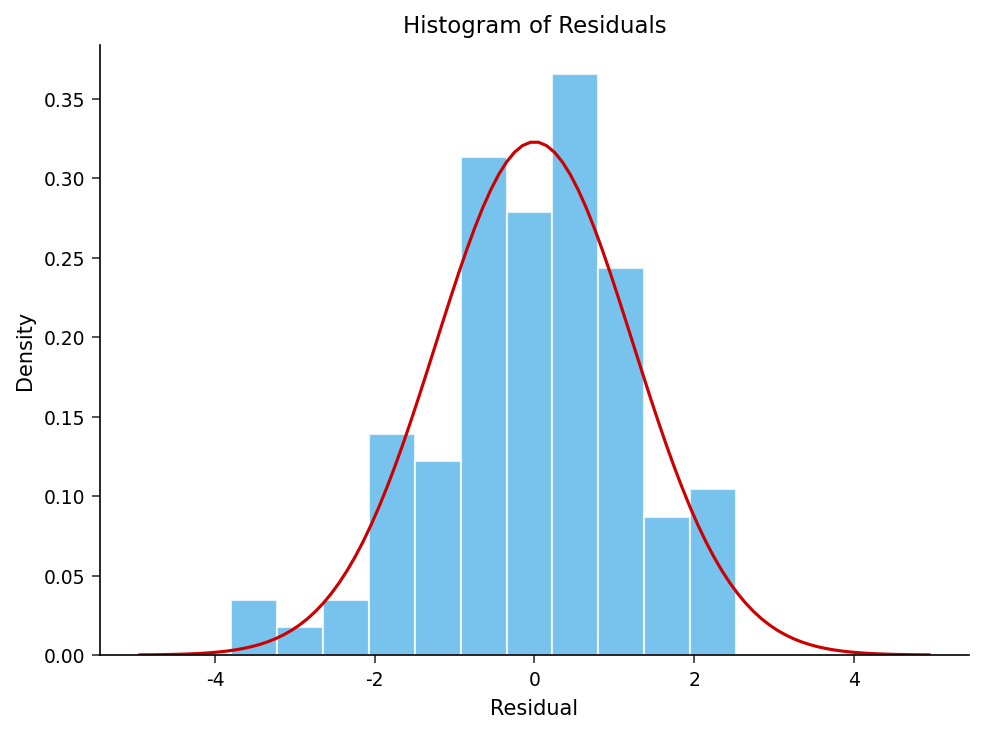

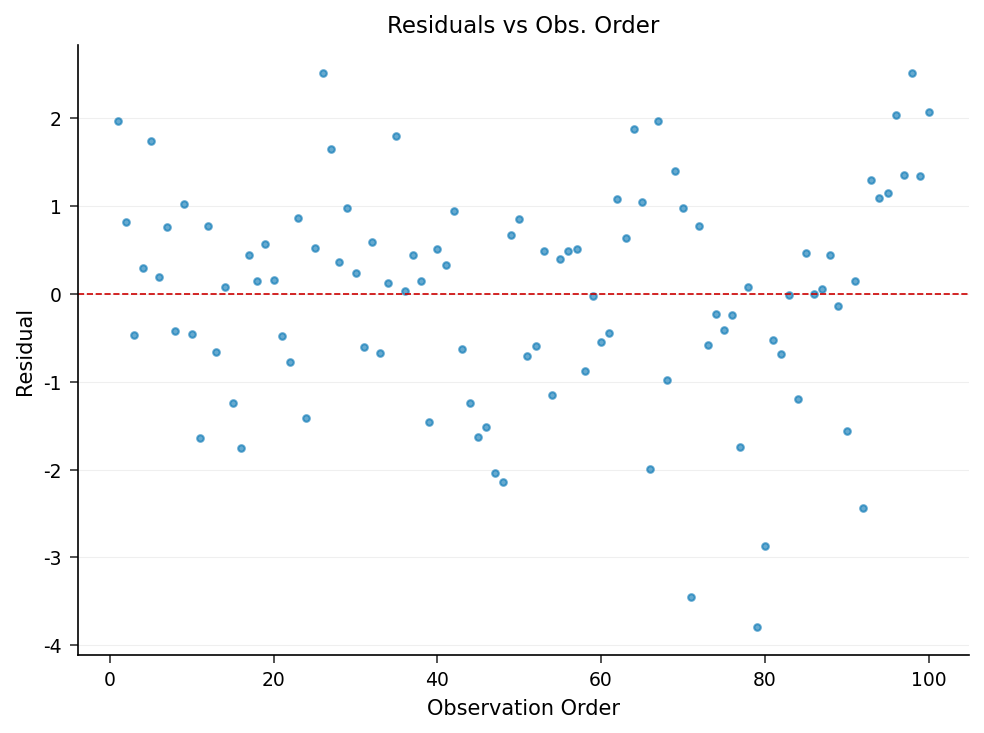

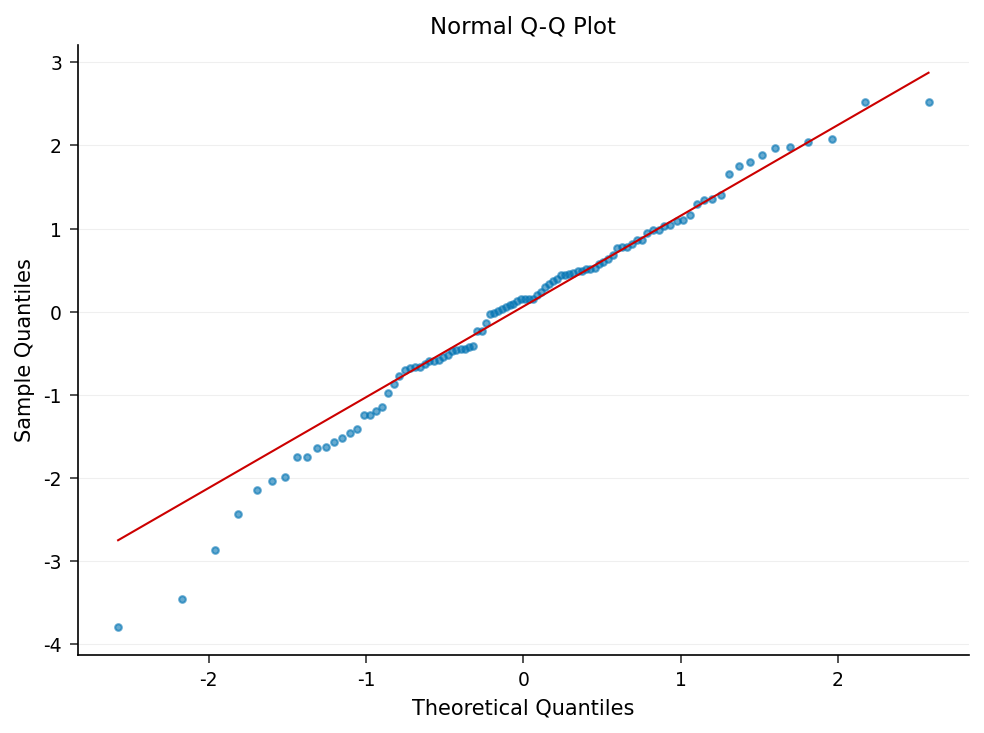

In [4]:
/* --------------------------------------------------------
   Split-plot mixad modellanalys
   Maskin är slumpmässig (whole-plot-fel)
   Hastighet är fix (sub-plot-faktor)
   -------------------------------------------------------- */
PROCEDUR MIXED data=work.molding_experiment METHOD=reml;
    KLASS machine speed_label;
    MODEL defect_rate = speed_label / SOLUTION ddfm=kr;
    RANDOM machine;
    LSMEANS speed_label / ADJUST=TUKEY DIFF cl;
    ODS OUTPUT LSMEANS=work.speed_lsmeans
              diffs=work.speed_diffs
              covparms=work.split_covparms
              fitstatistics=work.split_fit
              solutionf=work.split_fixed;
    ETIKETT machine="Maskin" speed_label="Hastighet" defect_rate="Felfrekvens (%)";
    TITEL 'Split-plot-analys: hastighetens effekt på felfrekvens';
KÖR;


In [5]:
/* --------------------------------------------------------
   Identifiera optimal hastighetsinställning
   -------------------------------------------------------- */
PROCEDUR SORTERA data=work.speed_lsmeans;
    EFTER estimate;
KÖR;

data work.optimal_speed;
    STÄLL_IN work.speed_lsmeans(obs=1);
    BEHÅLL speed_label estimate stderr lower upper;
    ETIKETT speed_label = 'Optimal hastighet'
          estimate = 'LS-medelvärde felfrekvens'
          lower = '95% KI nedre'
          upper = '95% KI övre';
KÖR;

PROCEDUR PRINT data=work.optimal_speed noobs label;
    TITEL 'Rekommenderad driftshastighet för lägsta felfrekvens';
KÖR;


                                  Rekommenderad driftshastighet för lägsta felfrekvens                                  

Optimal hastighet   LS-medelvärde felfrekvens  StdErr  95% KI nedre   95% KI övre
                .                       6.081  0.9266        3.3645        8.7975




NOTE: PROC SORT data=work.speed_lsmeans

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 5 rows from work.speed_lsmeans.
NOTE: Wrote work.speed_lsmeans (5 rows, 9 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.optimal_speed


NOTE: Read 1 rows from work.speed_lsmeans.
NOTE: Wrote work.optimal_speed (1 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.optimal_speed

NOTE: PROC PRINT completed: 1 observations printed, 5 variables


In [6]:
/* --------------------------------------------------------
   Nedbrytning av varianskomponenter
   -------------------------------------------------------- */
PROCEDUR PRINT data=work.split_covparms noobs;
    TITEL 'Variankomponenter: maskin kontra residual';
KÖR;


                                       Variankomponenter: maskin kontra residual                                        

  COVPARM  ESTIMATE
Intercept    3.1033
Residual     1.6566




NOTE: PROC PRINT data=work.split_covparms

NOTE: PROC PRINT completed: 2 observations printed, 2 variables


---

### Tolkning

Split-plot-modellen delar upp variabiliteten i felfrekvens i två stratum. **Maskinens (whole-plot) varianskomponent är 3.10** och **residualen (sub-plot) är 1.66**, så skillnader mellan maskiner står för ungefär **65%** av den totala variansen (3.10 / (3.10 + 1.66)). Denna stora andel mellan maskiner bekräftar att maskin är en verklig källa till processvariation och att split-plot-designen - snarare än en helt randomiserad analys - är det korrekta ramverket.

Typ III-testet av den fixa hastighetseffekten är starkt signifikant: **F(4, 92) = 60.26, p < .0001**, så RPM-inställningen påverkar felfrekvensen kraftigt. Minsta-kvadratmedelvärdena visar en tydlig kvadratisk respons med ett minimum vid mellanhastigheten:

| Hastighet | LS-medelvärde felfrekvens (%) | 95% KI |
|-------|------------------------|--------|
| **100 RPM** | **6.08** | 3.36 - 8.80 |
| 80 RPM | 7.74 | 5.02 - 10.46 |
| 120 RPM | 8.30 | 5.58 - 11.02 |
| 60 RPM | 10.02 | 7.31 - 12.74 |
| 140 RPM | 11.92 | 9.20 - 14.63 |

Tukey-justerade parvisa jämförelser visar att **100 RPM är signifikant lägre än varje annan inställning** (justerat p <= 0.0009 mot 80, 120, 60 och 140 RPM). Inställningarna 80 RPM och 120 RPM ligger i mitten och skiljer sig **inte** åt (skillnad 0.56, justerat p = 0.6430), medan 60 RPM och 140 RPM ger de högsta felfrekvenserna.

**Teknisk rekommendation:** standardisera produktionen vid **100 RPM** över alla fyra maskiner, där modellen skattar den lägsta felfrekvensen (6.08%). Eftersom maskinens varianskomponent (3.10) är den dominerande källan till variabilitet bör uppföljande arbete inriktas på maskinspecifik kalibrering - interaktionsprofilen visar att MACH_D genomgående ligger lägst och MACH_A högst - för att minska gapet mellan maskinerna vid den valda inställningen på 100 RPM.


---

In [7]:
/* --------------------------------------------------------
   Exportera hastighetsoptimeringsresultat för ingenjörer
   -------------------------------------------------------- */
PROCEDUR EXPORT data=work.speed_lsmeans
    OUTFILE='speed_optimization_lsmeans.csv'
    DBMS=csv REPLACE;
KÖR;

PROCEDUR EXPORT data=work.split_covparms
    OUTFILE='variance_components.csv'
    DBMS=csv REPLACE;
KÖR;



NOTE: PROC EXPORT data=work.speed_lsmeans outfile=speed_optimization_lsmeans.csv

NOTE: Exported 5 rows to speed_optimization_lsmeans.csv.
NOTE: PROC EXPORT data=work.split_covparms outfile=variance_components.csv

NOTE: Exported 2 rows to variance_components.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Konfidentiellt
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Drivs av <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>